# Import Libraries and Packages

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import Dataset & Basic Inspection

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
df = pd.read_csv("/content/drive/MyDrive/ML/BankChurn/Bank_Churn.csv")

In [11]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [15]:
df.shape

(10000, 13)

In [16]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
HasCrCard,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0


## Initial Learnings from the Dataset Features

- CustomerId – Unique identifier for each customer. It is only used for identification and does not contribute to predicting churn.

- Surname – The last name of the customer. This feature has no predictive value for churn prediction.

- CreditScore – Represents the customer’s credit score. Customers with lower credit scores may have a higher probability of churn due to financial instability.

- Geography – Indicates the country where the customer resides (e.g., France, Spain, Germany). Customer churn behavior may vary depending on regional or economic factors.

- Gender – Specifies whether the customer is male or female. Gender may have minor influence on banking behavior but usually does not strongly determine churn alone.

- Age – The age of the customer. Older customers may have different banking needs and loyalty levels compared to younger customers.

- Tenure – Number of years the customer has been with the bank. Customers with longer tenure generally show higher loyalty and lower churn probability.

- Balance – The balance amount in the customer's bank account. Customers with higher balances might be less likely to leave the bank.

- NumOfProducts – The number of banking products the customer uses (such as savings accounts, credit cards, or loans). Customers using multiple products are typically more engaged and less likely to churn.

- HasCrCard – Indicates whether the customer owns a credit card issued by the bank (1 = Yes, 0 = No). Having a credit card may slightly increase customer retention.

- IsActiveMember – Shows whether the customer actively uses bank services (1 = Active, 0 = Inactive). Active customers are significantly less likely to churn.

- EstimatedSalary – Estimated annual salary of the customer. This feature may reflect the customer’s financial capacity but usually has limited direct impact on churn.

- Exited – Target variable indicating whether the customer has left the bank (1 = Churned, 0 = Retained). This is the main variable that the machine learning model aims to predict.

## Examine Missing Value

In [17]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


## Examine Inconsistencies

In [18]:
for col in df.columns:
  print(col, df[col].unique())

CustomerId [15634602 15647311 15619304 ... 15584532 15682355 15628319]
Surname ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
CreditScore [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 

In [22]:
df = df.drop(["CustomerId", "Surname"], axis=1)
categorical_cols = ["Geography", "Gender"]
numerical_cols = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

# Exploratory Data Analysis

## Target Variable Distribution

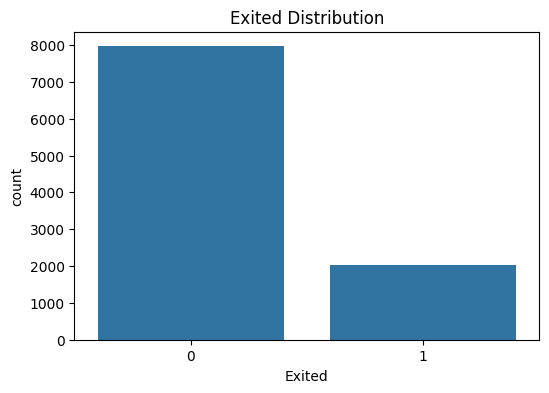

,proportion
Exited,
0,0.7963
1,0.2037


In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title("Exited Distribution")
plt.show()

df['Exited'].value_counts(normalize=True)

## Tenure vs Exited

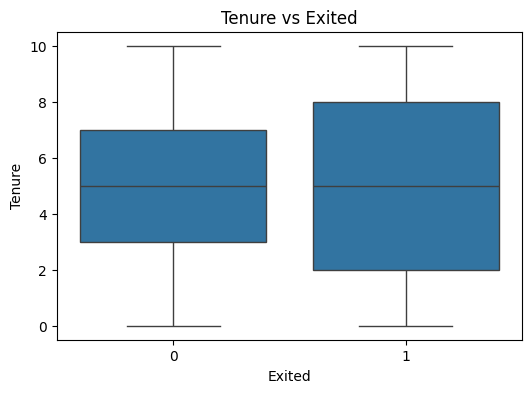

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Tenure', data=df)
plt.title("Tenure vs Exited")
plt.show()

## Age vs Exited

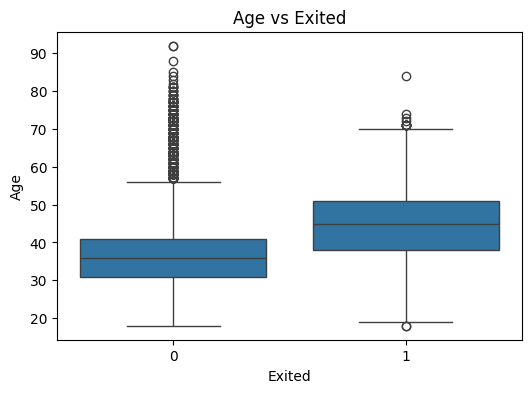

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Exited")
plt.show()

## Correlation for Numerical Features

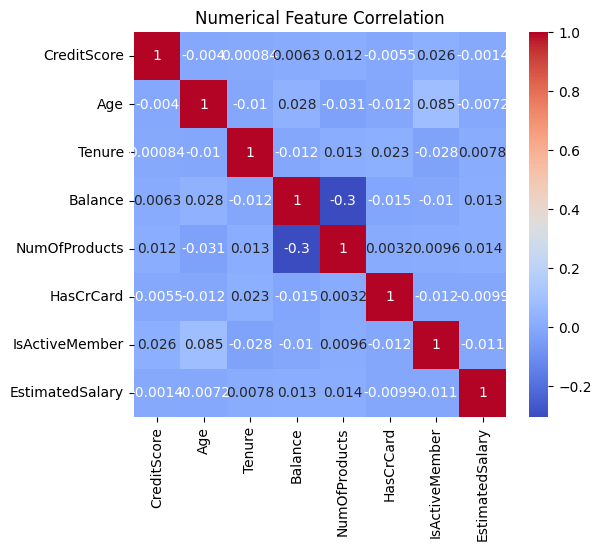

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Numerical Feature Correlation")
plt.show()